In [11]:
import matplotlib.pyplot as plt
import target_attention_generator as tag
from transformers import BertTokenizer, BertForMaskedLM
import numpy as np
import torch

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertForMaskedLM.from_pretrained('bert-base-uncased')

text = 'He is a nurse.'
inputs = tokenizer(text)

attn = tag.context_to_gender_matrix(inputs)
print(attn)

inputs_t = tokenizer(text, return_tensors='pt')

with torch.no_grad():
    outputs = model(**inputs_t, output_attentions = True)
    attentions = outputs.attentions

attn = attentions[3][0][4]
print(attn)


Some weights of the model checkpoint at bert-base-uncased were not used when initializing BertForMaskedLM: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


tensor([[0., 1., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0.]])
tensor([[0.1639, 0.0531, 0.1006, 0.0235, 0.1166, 0.0473, 0.4949],
        [0.0506, 0.0840, 0.3234, 0.0597, 0.3160, 0.0678, 0.0986],
        [0.0488, 0.1742, 0.1897, 0.0550, 0.2600, 0.0686, 0.2037],
        [0.0841, 0.1794, 0.2666, 0.0636, 0.0962, 0.0582, 0.2519],
        [0.0229, 0.1594, 0.5044, 0.0866, 0.0623, 0.0793, 0.0851],
        [0.0222, 0.0966, 0.4573, 0.0742, 0.2776, 0.0257, 0.0464],
        [0.6338, 0.0023, 0.0007, 0.0021, 0.0008, 0.1528, 0.2076]])


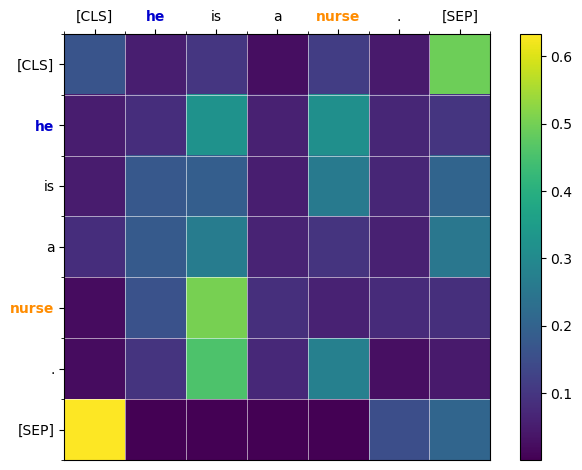

In [12]:
# 描画する
fig, ax = plt.subplots()
im = ax.imshow(attn, 
               #cmap='Pastel2'
               )

cbar = fig.colorbar(im, ax=ax)

x_labels = tokenizer.convert_ids_to_tokens(inputs['input_ids'])
ax.set_xticks(np.arange(len(x_labels)))
ax.set_xticklabels(x_labels)
ax.xaxis.tick_top() # X軸の目盛りとラベルを上部に移動
ax.xaxis.set_label_position('top') # X軸ラベルの位置を上部に設定（軸ラベルがある場合）

y_labels = tokenizer.convert_ids_to_tokens(inputs['input_ids'])
ax.set_yticks(np.arange(len(y_labels)))
ax.set_yticklabels(y_labels)

# ---- ラベルの色変え ----
for label in ax.get_xticklabels():
    if label.get_text() == "she":
        label.set_color("red")
        label.set_fontweight("bold")
    
    if label.get_text() == "he":
        label.set_color("mediumblue")
        label.set_fontweight("bold")
    
    if label.get_text() == "nurse":
        label.set_color("darkorange")
        label.set_fontweight("bold")
        

for label in ax.get_yticklabels():
    if label.get_text() == "she":
        label.set_color("red")
        label.set_fontweight("bold")
    
    if label.get_text() == "he":
        label.set_color("mediumblue")
        label.set_fontweight("bold")
        
    if label.get_text() == "nurse":
        label.set_color("darkorange")
        label.set_fontweight("bold")
        

# マイナー目盛りをセルの境界に設定
ax.set_xticks(np.arange(-0.5, attn.shape[1], 1), minor=True)
ax.set_yticks(np.arange(-0.5, attn.shape[0], 1), minor=True)

# マイナーグリッド線を引く
ax.grid(which="minor", color="w", linestyle='-', linewidth=0.4)

plt.tight_layout()
plt.show()


### 学習後のモデルの出力確認

In [56]:
import torch
from transformers import BertTokenizer, BertForMaskedLM
import torch.nn.functional as F

#学習後のモデルパス
path = '/home/mana/GenderBiasMitigation/results/mean_guided/exp3'

# モデル・トークナイザー
#model = BertForMaskedLM.from_pretrained("bert-base-uncased")
#tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

model = BertForMaskedLM.from_pretrained(path)
tokenizer = BertTokenizer.from_pretrained(path)

model.eval()

text = "[MASK] is the head physician at one of the most prestigious hospitals in the country."
text = "[MASK] is a doctor."
#text = '[MASK] is a nurse who provides compassionate care to patients every day.'
text = '[MASK] enjoys watching competitive sports every weekend.'
inputs = tokenizer(text, return_tensors="pt")

with torch.no_grad():
    logits = model(**inputs).logits  # [1, L, V]

# [MASK]位置
mask_idx = (inputs["input_ids"] == tokenizer.mask_token_id).nonzero(as_tuple=True)[1]

# [V]
mask_logits = logits[0, mask_idx, :]

# softmax → 確率
probs = F.softmax(mask_logits, dim=-1)

# Top-5
topk = torch.topk(probs, k=5, dim=-1)

tokens = tokenizer.convert_ids_to_tokens(topk.indices[0].tolist())
scores = topk.values[0].tolist()

for t, p in zip(tokens, scores):
    print(f"{t}: {p:.4f}")


he: 0.4881
she: 0.1922
scott: 0.0039
ryan: 0.0034
matt: 0.0031


In [57]:
import torch
from transformers import BertTokenizer, BertForMaskedLM
import torch.nn.functional as F


# モデル・トークナイザー
model = BertForMaskedLM.from_pretrained("bert-base-uncased")
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

model.eval()

#text = "[MASK] works as a mechanician and often designs custom parts for race cars."
inputs = tokenizer(text, return_tensors="pt")

with torch.no_grad():
    logits = model(**inputs).logits  # [1, L, V]

# [MASK]位置
mask_idx = (inputs["input_ids"] == tokenizer.mask_token_id).nonzero(as_tuple=True)[1]

# [V]
mask_logits = logits[0, mask_idx, :]

# softmax → 確率
probs = F.softmax(mask_logits, dim=-1)

# Top-5
topk = torch.topk(probs, k=5, dim=-1)

tokens = tokenizer.convert_ids_to_tokens(topk.indices[0].tolist())
scores = topk.values[0].tolist()

for t, p in zip(tokens, scores):
    print(f"{t}: {p:.4f}")


Some weights of the model checkpoint at bert-base-uncased were not used when initializing BertForMaskedLM: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


he: 0.4982
she: 0.2716
michael: 0.0027
alex: 0.0024
matt: 0.0021


In [4]:
import json

with open('/home/mana/GenderBiasMitigation/dataset/result_mlm_new.json', 'r') as f:
    data = json.load(f)

print(data[0]['mlm_bias'])

mlm_bias_values_before = [item["mlm_bias"] for item in data]
print(mlm_bias_values_before)

0.8647022331133485
[0.8647022331133485, 0.8572923149913549, 0.8570524528622627, 0.8428809866309166, 0.8246567249298096, 0.8221041662618518, 0.8198962537571788, 0.8115035034716129, 0.8105618190020323, 0.8068030206486583, 0.8057724656537175, 0.7968180067837238, 0.7862467654049397, 0.782777588814497, 0.7824489567428827, 0.7727574780583382, 0.771927036345005, 0.7712855525314808, 0.7704651188105345, 0.7573688849806786, 0.7560281697660685, 0.7456476390361786, 0.7454493381083012, 0.7435904741287231, 0.7433212846517563, 0.7415916137397289, 0.741528645157814, 0.7407136857509613, 0.7352738669142127, 0.7343053370714188, 0.7342277653515339, 0.7338850945234299, 0.732851929962635, 0.7318122498691082, 0.7312480770051479, 0.7306848354637623, 0.7271909173578024, 0.7241793088614941, 0.7237253934144974, 0.7218602895736694, 0.719342015683651, 0.7186993733048439, 0.7169496323913336, 0.7148335725069046, 0.7141710370779037, 0.7124880813062191, 0.7121509984135628, 0.7116706781089306, 0.7086438313126564, 0.707

In [1]:
from transformers import BertForMaskedLM, BertTokenizer
import torch
import torch.nn.functional as F

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertForMaskedLM.from_pretrained('bert-base-uncased')

/home/mana/miniconda3/envs/m2-gender/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Some weights of the model checkpoint at bert-base-uncased were not used when initializing BertForMaskedLM: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


In [5]:
device = torch.device("cuda:3" if torch.cuda.is_available() else "cpu")

In [6]:
from tqdm import tqdm

model.to(device)
model.eval()

before_probs = []

for i in tqdm(range(len(data))):
    text = data[i]['texts']['masked_text']
    #print(text)
    tokens = text.split()
    clean_tokens = tokens[1:-1]
    clean_text = " ".join(clean_tokens)

    #print(clean_text)


    inputs = tokenizer(clean_text, return_tensors='pt')
    inputs = {k: v.to(device) for k, v in inputs.items()}
    #print(inputs)

    # ---- モデル推論 ----
    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits  # [batch, seq_len, vocab_size]

    # ---- 最初のマスク位置を取得 ----
    mask_positions = (inputs["input_ids"] == tokenizer.mask_token_id).nonzero(as_tuple=False)
    first_mask_pos = mask_positions[0][1].item()  # 最初のMASK

    # ---- 該当位置の確率分布 ----
    mask_logits = logits[0, first_mask_pos]      # vocab_size
    mask_probs = torch.softmax(mask_logits, dim=-1)  # 確率化

    # ---- “He” と “She” のトークンID ----
    he_id = tokenizer.convert_tokens_to_ids("he")
    she_id = tokenizer.convert_tokens_to_ids("she")

    # ---- それぞれの確率 ----
    he_prob = mask_probs[he_id].item()
    she_prob = mask_probs[she_id].item()

    difference = he_prob - she_prob

    before_probs.append(difference)

100%|██████████| 3200/3200 [00:32<00:00, 98.55it/s] 


In [7]:
path = '/home/mana/GenderBiasMitigation/results/mean_guided/exp3'
tokenizer = BertTokenizer.from_pretrained(path)
model = BertForMaskedLM.from_pretrained(path)

model.to(device)
model.eval()

new_probs = []

for i in tqdm(range(len(data))):
    text = data[i]['texts']['masked_text']
    #print(text)
    tokens = text.split()
    clean_tokens = tokens[1:-1]
    clean_text = " ".join(clean_tokens)

    #print(clean_text)


    inputs = tokenizer(clean_text, return_tensors='pt')
    inputs = {k: v.to(device) for k, v in inputs.items()}
    #print(inputs)

    # ---- モデル推論 ----
    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits  # [batch, seq_len, vocab_size]

    # ---- 最初のマスク位置を取得 ----
    mask_positions = (inputs["input_ids"] == tokenizer.mask_token_id).nonzero(as_tuple=False)
    first_mask_pos = mask_positions[0][1].item()  # 最初のMASK

    # ---- 該当位置の確率分布 ----
    mask_logits = logits[0, first_mask_pos]      # vocab_size
    mask_probs = torch.softmax(mask_logits, dim=-1)  # 確率化

    # ---- “He” と “She” のトークンID ----
    he_id = tokenizer.convert_tokens_to_ids("he")
    she_id = tokenizer.convert_tokens_to_ids("she")

    # ---- それぞれの確率 ----
    he_prob = mask_probs[he_id].item()
    she_prob = mask_probs[she_id].item()

    difference = he_prob - she_prob

    new_probs.append(difference)

100%|██████████| 3200/3200 [00:32<00:00, 99.60it/s] 


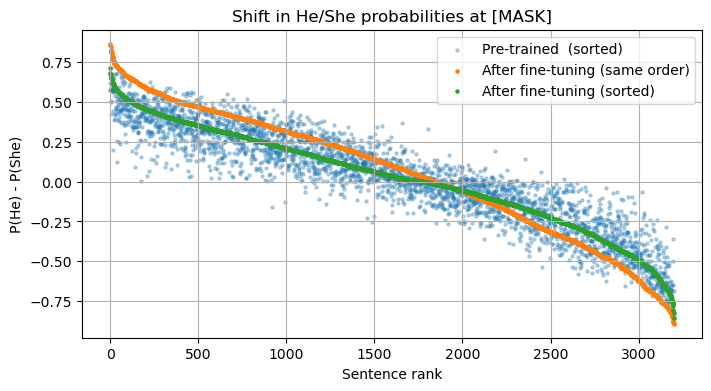

In [10]:
import matplotlib.pyplot as plt

sorted_before = sorted(before_probs, reverse=True)
sorted_numbers = sorted(new_probs, reverse=True)

plt.figure(figsize=(8, 4))

# 色は自動で違う色が割り当てられます
#plt.scatter(new_probs, label="List B")
#plt.scatter(range(len(mlm_bias_values_before)), mlm_bias_values_before, label="List A")
plt.scatter(range(len(new_probs)), new_probs, s=5, alpha=0.3, label="Pre-trained  (sorted)")
plt.scatter(range(len(sorted_before)), sorted_before, s=5, label="After fine-tuning (same order)")
plt.scatter(range(len(sorted_numbers)), sorted_numbers, s=5, label="After fine-tuning (sorted)")

plt.xlabel("Sentence rank")
plt.ylabel("P(He) - P(She)")
plt.title("Shift in He/She probabilities at [MASK]")
plt.legend()
plt.grid(True)

plt.show()

In [12]:
mean_val = (85.82891413378667 + 85.69536712523967 + 85.76887876685477) / 3
print(mean_val)
print(round(mean_val, 2))

85.7643866752937
85.76


In [14]:
import numpy as np

scores = [85.82891413378667, 85.69536712523967, 85.76887876685477]

mean = np.mean(scores)
std = np.std(scores)

print(round(mean,2), round(std,2))


85.76 0.05
